# 1. BUSINESS UNDERSTANDING

## Problem Statement

Streaming platforms such as Netflix, Disney+, Amazon prime among others face a challenge:
`Users are overwhelmed by thousands of movie choices.`

The objective is to develop an intelligent recommendation system, that is capable of predicting movies that a user is likely to enjoy based on:
- Historical ratings
- Movie genres
- User preferences
- Similar users and movies

## Business objectives

Build a Recommendation system that:
- Improves user engagement
- Personalizes user experience
- Increases watch time
- Reduces search effort

## Success Criteria

The recommendation system will be considered successful if it achieves low RMSE and MAE values while maintaining high Precision@10 and Recall@10 scores.

# 2. DATA UNDERSTANDING

In [1]:
# installing necessary libraries
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud

# Recommendation Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import train_test_split

from scipy.sparse import csr_matrix

from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import KNNBasic
from surprise import accuracy
from surprise.model_selection import train_test_split as surprise_split

# Statistics
from scipy.stats import skew

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the datasets

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")

`dataset inspection`

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [6]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [7]:
movies.info()
ratings.info()
tags.info()
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-nul

In [8]:
movies.shape
ratings.shape
tags.shape
links.shape

(9742, 3)

### EXPLORATORY DATA ANALYSIS (EDA)

#### Ratings Distribution

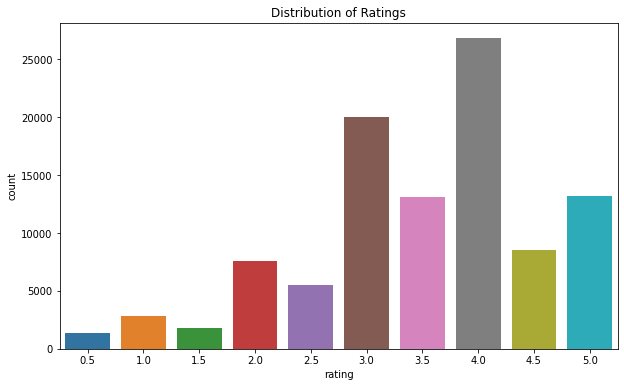

In [9]:
plt.figure(figsize=(10,6))
sns.countplot(x='rating', data=ratings)
plt.title('Distribution of Ratings')
plt.show()

Users rarely give extremely low Ratings. 
This can create rating bias

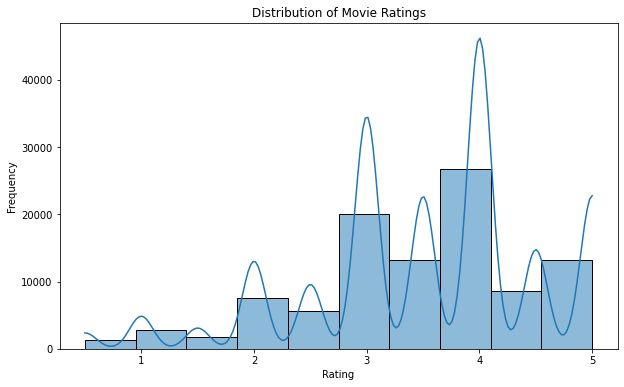

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    ratings['rating'],
    bins=10,
    edgecolor='black',
    kde=True
)

plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

This suggests most movies recieve favorable feedback

#### Top 20 most rated Movies

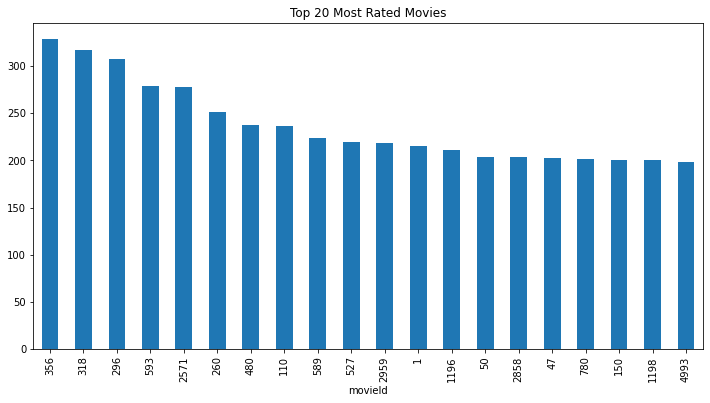

In [11]:
movie_ratings = ratings.groupby(
    'movieId'
)['rating'].count()

top_movies = movie_ratings.sort_values(
    ascending=False
).head(20)

top_movies.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Top 20 Most Rated Movies")
plt.show()

Popular movies often dominate recommendations. Most users will recommend them to their friends.

#### Ratings per user

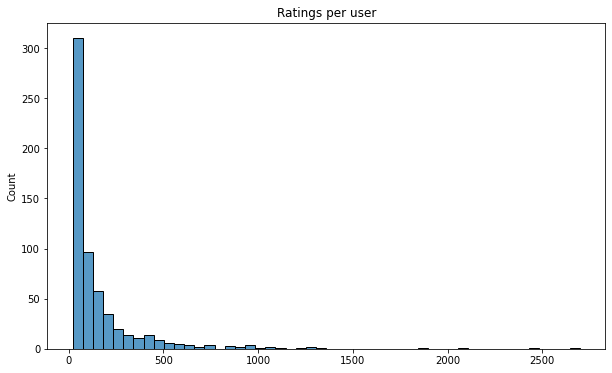

In [12]:
user_counts = ratings.groupby('userId').size()
plt.figure(figsize=(10,6))
sns.histplot(user_counts,bins=50)
plt.title('Ratings per user')
plt.show()

#### Top User Leaderboard

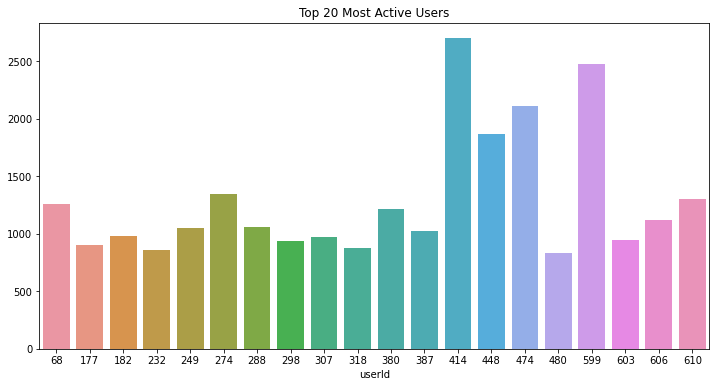

In [13]:
top_users = ratings.groupby(
    'userId'
).size().sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_users.index,
    y=top_users.values
)

plt.title("Top 20 Most Active Users")
plt.show()

A small number of users contribute a disproportionately large number of ratings. These users provide valuable information for recommendation algorithm.

#### Top genres by Average Rating

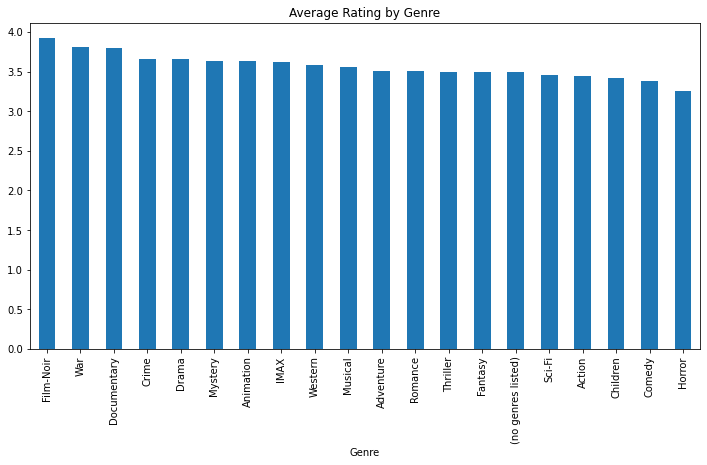

In [14]:
movie_data = pd.merge(
    ratings,
    movies,
    on='movieId'
)

genre_ratings = []

for _, row in movie_data.iterrows():

    genres = row['genres'].split('|')

    for genre in genres:

        genre_ratings.append(
            [genre,row['rating']]
        )

genre_df = pd.DataFrame(
    genre_ratings,
    columns=['Genre','Rating']
)

avg_genre = genre_df.groupby(
    'Genre'
)['Rating'].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

avg_genre.plot(kind='bar')

plt.title(
    "Average Rating by Genre"
)

plt.show()

Some genres consistently receive higher ratings, indicating stronger audience preference.

#### Movie Genre distribution

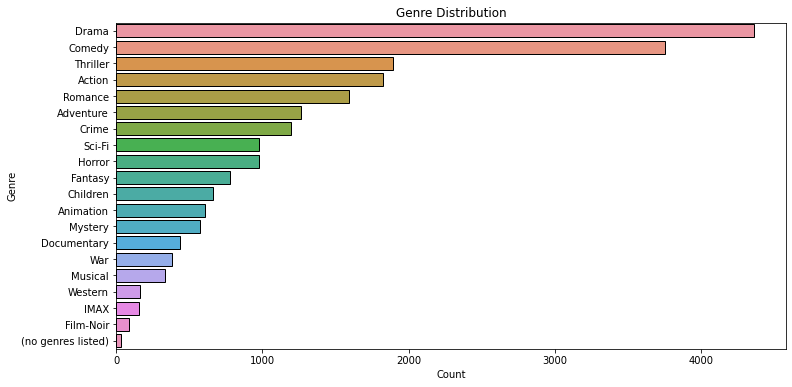

In [15]:
genres = movies['genres'].str.split('|')

genre_list = []

for row in genres:
    genre_list.extend(row)

genre_df = pd.Series(genre_list)

plt.figure(figsize=(12, 6))

sns.countplot(
    y=genre_df,
    order=genre_df.value_counts().index,
    edgecolor='black'
)

plt.title("Genre Distribution")
plt.xlabel("Count")
plt.ylabel("Genre")

plt.show()

Genres like Drama, Comedy ususally dominate MovieLens indicating huge audience. Western, IMAX, Film-Noir have a low audience hence they are not highly recommended.

#### Wordcloud of Tags

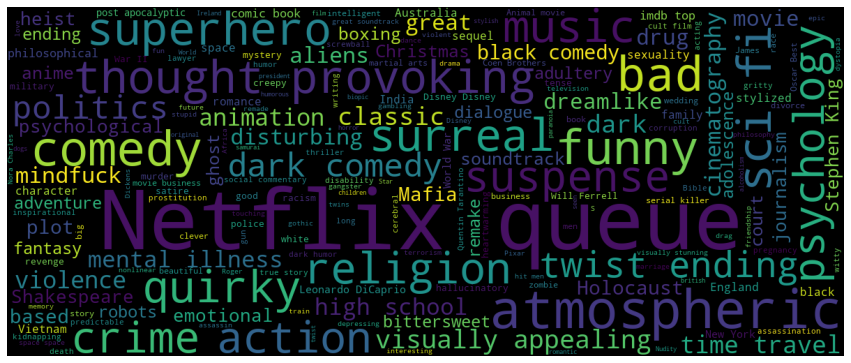

In [16]:
text = " ".join(tags['tag'].dropna())

wordcloud = WordCloud(
    width=1200,
    height=500,
    background_color='black'
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Larger words = more common tags.
This provides insight into user perceptions.

#### User activity distribution

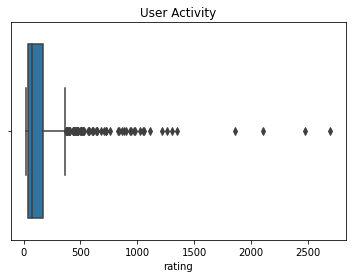

In [17]:
activity = ratings.groupby('userId')['rating'].count()

sns.boxplot(activity)
plt.title('User Activity')
plt.show()

shows:
- median activity
- Outliers
This means that most users rate few movies and some users rate many.

#### Rating timeline trends

<Axes: xlabel='date'>

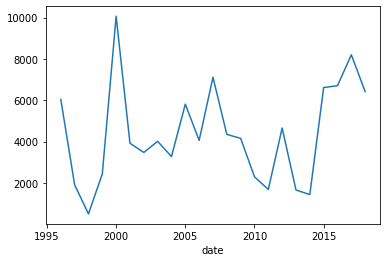

In [18]:
ratings['date'] = pd.to_datetime(
    ratings['timestamp'],
    unit='s'
)

ratings.groupby(
    ratings['date'].dt.year
).size().plot()

The rating timeline trend illustrates how user engagement changed over time. An increasing number of ratings indicates growing platform activity and user participation. This suggests that the recommendation system has access to a richer historical dataset for learning user preferences. A decline in ratings would indicate reduced engagement and potentially less reliable recommendation performance.

#### Movie Porpularity vs Rating

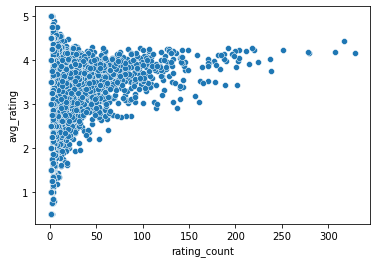

In [19]:
movie_stats = ratings.groupby(
    'movieId'
).agg({
    'rating':['mean','count']
})

movie_stats.columns = [
    'avg_rating',
    'rating_count'
]

sns.scatterplot(
    data=movie_stats,
    x='rating_count',
    y='avg_rating'
)
plt.show()

#### Correlation Heatmap

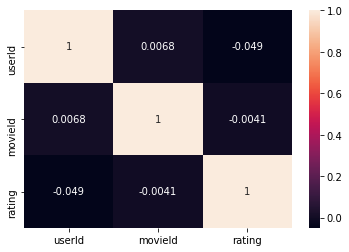

In [20]:
numeric_data = ratings[['userId','movieId','rating']]

sns.heatmap(
    numeric_data.corr(),
    annot=True
)

plt.show()

This shows the relationship among UserId, MovieId, and Ratings. 

# 3. DATA PREPERATION

In [21]:
# Checking for duplicates
movies.duplicated().sum()
ratings.duplicated().sum()

0

Duplicate observations were checked to avoid biasing recommendation results.

In [22]:
# Finding missing values
movies.isnull().sum()
ratings.isnull().sum()
tags.isnull().sum()
links.isnull().sum()

movieId    0
imdbId     0
tmdbId     8
dtype: int64

Missing values were checked to ensure data quality prior to modeling.

In [23]:
# Merging movies and ratings datasets

movie_data = pd.merge(
    ratings,
    movies,
    on='movieId'
)

movie_data.head()

,userId,movieId,rating,timestamp,date,title,genres
0,1,1,4.0,964982703,2000-07-30 18:45:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,5,1,4.0,847434962,1996-11-08 06:36:02,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,7,1,4.5,1106635946,2005-01-25 06:52:26,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
3,15,1,2.5,1510577970,2017-11-13 12:59:30,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
4,17,1,4.5,1305696483,2011-05-18 05:28:03,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy


By merging these datasets they allow for recommendations using both movie and rating information.

#### Creating Popularity metrics

In [24]:
movie_summary = movie_data.groupby(
    'title'
).agg({
    'rating':['mean','count']
})

movie_summary.columns = [
    'average_rating',
    'number_of_ratings'
]

movie_summary

,average_rating,number_of_ratings
title,,
'71 (2014),4.000000,1
'Hellboy': The Seeds of Creation (2004),4.000000,1
'Round Midnight (1986),3.500000,2
'Salem's Lot (2004),5.000000,1
'Til There Was You (1997),4.000000,2
...,...,...
eXistenZ (1999),3.863636,22
xXx (2002),2.770833,24
xXx: State of the Union (2005),2.000000,5


##### Weighted Rating

In [25]:
 
c = movie_summary['average_rating'].mean()
m = movie_summary['number_of_ratings'].quantile(0.90)

print(c)
print(m)

3.2623883953257353
27.0


Balances:

- Rating quality
- Rating quantity

This prevents movies with only 1 rating from ranking first

#### User-Item Matrix Sparcity

In [26]:
sparsity = (
    1 -
    len(ratings) /
    (
        ratings.userId.nunique() *
        ratings.movieId.nunique()
    )
)

print(
    f"Sparsity: {sparsity:.2%}"
)

Sparsity: 98.30%


The matrix is highly sparse, indicating that most users rate only a small subset of available movies.

# 4. MODELLING

#### Model 1: Popularity based Recommendation

In [27]:
popular_movies = movie_summary.sort_values(
    ['average_rating','number_of_ratings'],
    ascending=False
)

popular_movies.head(10)

,average_rating,number_of_ratings
title,,
Belle époque (1992),5.0,2
Come and See (Idi i smotri) (1985),5.0,2
Enter the Void (2009),5.0,2
Heidi Fleiss: Hollywood Madam (1995),5.0,2
Jonah Who Will Be 25 in the Year 2000 (Jonas qui aura 25 ans en l'an 2000) (1976),5.0,2
Lamerica (1994),5.0,2
Lesson Faust (1994),5.0,2
'Salem's Lot (2004),5.0,1
12 Angry Men (1997),5.0,1


The system identifies universally liked movies.

These movies have:

- High satisfaction levels
- Large audience support

Such movies are safe recommendations for new users.

Limitation
- Cannot personalize recommendations
- every user recieves the same recommendations.

#### Model 2: Content-Based Filtering
TF-IDF

In [28]:
movies['genres'] = movies[
    'genres'
].fillna('')

tfidf = TfidfVectorizer(
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(
    movies['genres']
)

print(movies['genres'])

0       Adventure|Animation|Children|Comedy|Fantasy
1                        Adventure|Children|Fantasy
2                                    Comedy|Romance
3                              Comedy|Drama|Romance
4                                            Comedy
                           ...                     
9737                Action|Animation|Comedy|Fantasy
9738                       Animation|Comedy|Fantasy
9739                                          Drama
9740                               Action|Animation
9741                                         Comedy
Name: genres, Length: 9742, dtype: object


The model converts textual information into machine-readable features.

Movies sharing similar genres receive similar vector representations.

###### Cosine Similarity

In [29]:

cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

cosine_sim

array([[1.        , 0.81357774, 0.15276924, ..., 0.        , 0.4210373 ,
        0.26758648],
       [0.81357774, 1.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.15276924, 0.        , 1.        , ..., 0.        , 0.        ,
        0.57091541],
       ...,
       [0.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.4210373 , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.26758648, 0.        , 0.57091541, ..., 0.        , 0.        ,
        1.        ]])

Similarity is calculated between every pair of movies.

A score near 1: - meeans movies share similar genres

A score near 0: - means they are unrelated

##### Recommendation Function

In [30]:

indices = pd.Series(
    movies.index,
    index=movies['title']
)

def recommend_content(title):

    idx = indices[title]

    sim_scores = list(
        enumerate(cosine_sim[idx])
    )

    sim_scores = sorted(
        sim_scores,
        key=lambda x:x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:11]

    movie_indices = [
        i[0]
        for i in sim_scores
    ]

    return movies[
        'title'
    ].iloc[movie_indices]

print(indices)

title
Toy Story (1995)                                0
Jumanji (1995)                                  1
Grumpier Old Men (1995)                         2
Waiting to Exhale (1995)                        3
Father of the Bride Part II (1995)              4
                                             ... 
Black Butler: Book of the Atlantic (2017)    9737
No Game No Life: Zero (2017)                 9738
Flint (2017)                                 9739
Bungo Stray Dogs: Dead Apple (2018)          9740
Andrew Dice Clay: Dice Rules (1991)          9741
Length: 9742, dtype: int64


All recommendations share similar characteristics.

The system recommends movies based on content similarity rather than user behaviour.

Limitation: - Users may receive very similar recommendations repeatedly.

#### Model 3: User-Based Collaborative Filtering

In [31]:
# Creating user-item matrix

user_movie_matrix = movie_data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

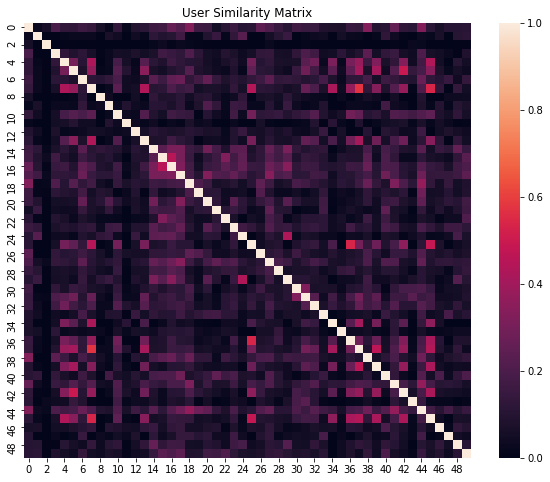

In [32]:
# Finding similar users
user_similarity = cosine_similarity(user_movie_matrix.fillna(0))

plt.figure(figsize=(10,8))
sns.heatmap(user_similarity[:50,:50])
plt.title('User Similarity Matrix')
plt.show()

This shows the similarity scores between users based on their historical ratings. Darker regions represent users with highly similar movie preferences, while lighter regions indicate users with dissimilar tastes.

Presence of clusters suggests that groups of users share common interests, making user-based collaborative filtering suitable for generating personalized recommenndations.

#### Model 4: Item-Based Collaborative Filtering

In [33]:
movie_similarity = cosine_similarity(
    user_movie_matrix.fillna(0).T
)

In [34]:
# Movie Recommendation Function

def item_based_recommend(movie_name):

    movie_index = user_movie_matrix.columns.get_loc(
        movie_name
    )

    similarities = movie_similarity[
        movie_index
    ]

    similar_movies = pd.Series(
        similarities,
        index=user_movie_matrix.columns
    )

    return similar_movies.sort_values(
        ascending=False
    )[1:11]

recommendations = item_based_recommend('Toy Story (1995)')

print(recommendations.index.tolist())

['Toy Story 2 (1999)', 'Jurassic Park (1993)', 'Independence Day (a.k.a. ID4) (1996)', 'Star Wars: Episode IV - A New Hope (1977)', 'Forrest Gump (1994)', 'Lion King, The (1994)', 'Star Wars: Episode VI - Return of the Jedi (1983)', 'Mission: Impossible (1996)', 'Groundhog Day (1993)', 'Back to the Future (1985)']


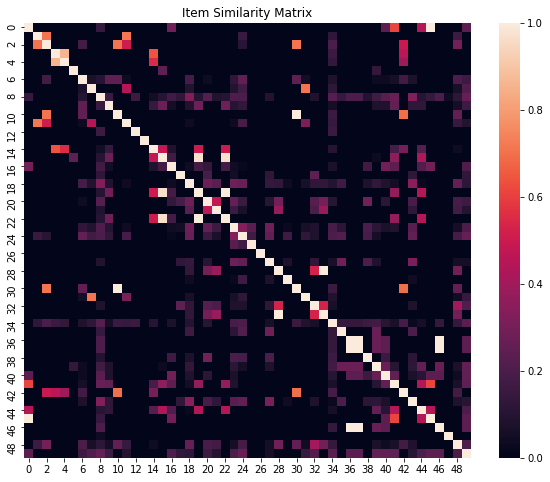

In [35]:
plt.figure(figsize=(10,8))

sns.heatmap(
    movie_similarity[:50,:50]
)

plt.title(
    "Item Similarity Matrix"
)

plt.show()

This shows how similar movies are based on user rating behaviour. Movies with high similarity scores tend to be liked by the same users and therefore form natural recommendation clusters.

This visualization supports the use of item-based collaborative filtering because similar movies can be recommended to users who enjoyed related content.

#### Model 5: Matrix Factorization (SVD)

SVD learns hidden latent factors describing user preferences and movie characteristics.

In [36]:
# Preparing the dataset  
reader = Reader(
    rating_scale=(0.5,5)
)

data = Dataset.load_from_df(
    ratings[
        ['userId',
         'movieId',
         'rating']
    ],
    reader
)

In [37]:
# Train/Test split
trainset, testset = surprise_split(
    data,
    test_size=0.2,
    random_state=42
)

The ratings dataset was divided into training and testing sets. The training set was used to learn user-item interactions while the testing set was reserved for evaluating model performance on unseen ratings.

In [38]:
# training SVD
svd = SVD()
svd.fit(trainset)

# Predictions
prediction = svd.test(testset)

# Evaluation
accuracy.rmse(prediction)
accuracy.mae(prediction)

RMSE: 0.8798
MAE:  0.6764


0.67637744416703

In [39]:
from surprise import KNNBasic
knn_user = KNNBasic(
    sim_options={
        'name': 'cosine',
        'user_based': True
    }
)

In [40]:
# For user based 
knn_user.fit(trainset)

pred_user = knn_user.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


In [41]:
knn_item = KNNBasic(
    sim_options={
        'name': 'cosine',
        'user_based': False
    }
)

In [42]:
# For item based 
knn_item.fit(trainset)

pred_item = knn_item.test(testset)

Computing the cosine similarity matrix...
Done computing similarity matrix.


SVD Latent Factor Visualization

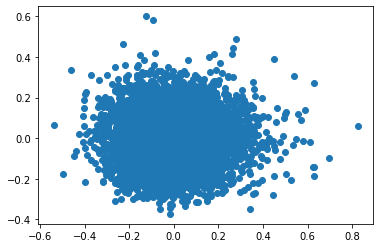

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

movie_factors_2d = pca.fit_transform(
    svd.qi
)

plt.scatter(
    movie_factors_2d[:,0],
    movie_factors_2d[:,1]
)

The PCA projection of SVD latent factors provides a two-dimensional representation of the hidden features learned by the matrix factorization model.

Movies positioned close together share similar latennt characteristics and appeal to similar user groups.

This demonstrates that SVD successfully captures underlying preference patterns that are not directly observable in movie genres or ratings alone.

# 5. EVALUATION

#### Step 1: RMSE Comparison

In [44]:
# For SVD(Surprise)
from surprise import accuracy

predictions = svd.test(testset)

rmse_svd = accuracy.rmse(
    predictions,
    verbose=False
)

print("SVD RMSE:", rmse_svd)

SVD RMSE: 0.8798041217051782


SVD produces the smallest prediction error.

Meaning:

Predicted ratings are closest to actual user ratings.

Lower RMSE = Better model

In [45]:
# For KNN User-Based
knn_user = KNNBasic(
    sim_options={
        'name':'cosine',
        'user_based':True
    }
)

knn_user.fit(trainset)

pred_user = knn_user.test(testset)

rmse_user = accuracy.rmse(
    pred_user,
    verbose=False
)

print(rmse_user)

Computing the cosine similarity matrix...
Done computing similarity matrix.
0.9822558142846856


In [46]:
# For KNN Item-Based
knn_item = KNNBasic(
    sim_options={
        'name':'cosine',
        'user_based':False
    }
)

knn_item.fit(trainset)

pred_item = knn_item.test(testset)

rmse_item = accuracy.rmse(
    pred_item,
    verbose=False
)

print(rmse_item)

Computing the cosine similarity matrix...
Done computing similarity matrix.
0.97995665962038


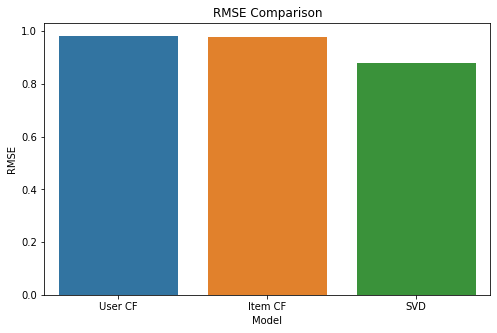

In [47]:
rmse_results = pd.DataFrame({
    'Model':['User CF','Item CF','SVD'],
    'RMSE':[rmse_user,
            rmse_item,
            rmse_svd]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=rmse_results,
    x='Model',
    y='RMSE'
)

plt.title("RMSE Comparison")
plt.show()

On average, SVD's predictions differ from actual user ratings by approximately 0.88 rating points, while User-Based and Item-Based Collaborative Filtering differ by approximately 0.98 rating points.

SVD achieved the lowest RMSE and therefore provided the most accurate rating predictions among the evaluated models.

#### STEP 2: MAE COMPARISON

In [48]:
# SVD
mae_svd = accuracy.mae(
    predictions,
    verbose=False
)

print(mae_svd)

0.67637744416703


In [49]:
# User CF
mae_user = accuracy.mae(
    pred_user,
    verbose=False
)

# Item CF
mae_item = accuracy.mae(
    pred_item,
    verbose=False
)
mae_user

0.7558972904135215

On average:

SVD misses by only 0.68 stars

compared with:

User CF misses by 0.76 stars

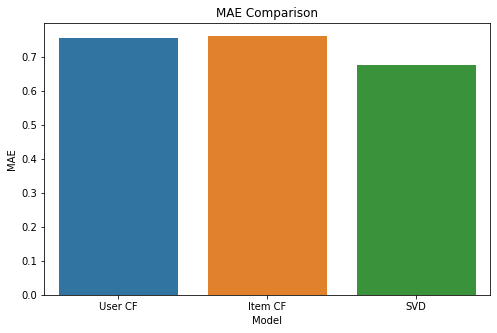

In [50]:
mae_results = pd.DataFrame({
    'Model':['User CF',
             'Item CF',
             'SVD'],
    'MAE':[mae_user,
           mae_item,
           mae_svd]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=mae_results,
    x='Model',
    y='MAE'
)

plt.title("MAE Comparison")
plt.show()

The SVD model misses the true rating by approximately 0.68 stars on average, whereas User-Based Collaborative Filtering misses by approximately 0.76 stars.

The lower MAE obtained by SVD confirms that it consistently produces more accurate predictions than the collaborative filtering approaches.

#### STEP 3: PRECISION@K

This evaluates recommendation quality rather than rating prediction.

In [51]:
from collections import defaultdict
import numpy as np

def precision_recall_at_k(predictions,
                          k=10,
                          threshold=4):

    user_est_true = defaultdict(list)

    # Store predictions per user
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions = {}
    recalls = {}

    for uid, user_ratings in user_est_true.items():

        # Sort by estimated rating
        user_ratings.sort(
            key=lambda x: x[0],
            reverse=True
        )

        # Number of relevant items
        n_rel = sum(
            (true_r >= threshold)
            for (_, true_r) in user_ratings
        )

        # Number of recommended items in Top-K
        n_rec_k = sum(
            (est >= threshold)
            for (est, _) in user_ratings[:k]
        )

        # Number of relevant recommended items in Top-K
        n_rel_and_rec_k = sum(
            (
                (true_r >= threshold)
                and
                (est >= threshold)
            )
            for (est, true_r)
            in user_ratings[:k]
        )

        precisions[uid] = (
            n_rel_and_rec_k / n_rec_k
            if n_rec_k != 0 else 0
        )

        recalls[uid] = (
            n_rel_and_rec_k / n_rel
            if n_rel != 0 else 0
        )

    return precisions, recalls

In [52]:
# For SVD
precisions_svd, recalls_svd = precision_recall_at_k(
    predictions,
    k=10,
    threshold=4
)

precision_svd = np.mean(
    list(precisions_svd.values())
)

recall_svd = np.mean(
    list(recalls_svd.values())
)

print("SVD Precision@10:", precision_svd)

SVD Precision@10: 0.5791907364038512


In [53]:
# For User-Based CF
precisions_user, recalls_user = precision_recall_at_k(
    pred_user,
    k=10,
    threshold=4
)

precision_user = np.mean(
    list(precisions_user.values())
)

recall_user = np.mean(
    list(recalls_user.values())
)

print("User CF Precision@10:", precision_user)

User CF Precision@10: 0.6592642466822795


In [54]:
precisions_item, recalls_item = precision_recall_at_k(
    pred_item,
    k=10,
    threshold=4
)

precision_item = np.mean(
    list(precisions_item.values())
)

recall_item = np.mean(
    list(recalls_item.values())
)

print("Item CF Precision@10:", precision_item)

Item CF Precision@10: 0.3116126723913609


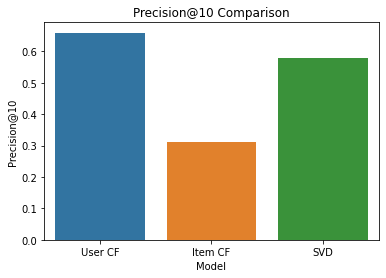

In [55]:
precision_df = pd.DataFrame({
    'Model':['User CF',
             'Item CF',
             'SVD'],
    'Precision@10':[
        precision_user,
        precision_item,
        precision_svd
    ]
})

sns.barplot(
    data=precision_df,
    x='Model',
    y='Precision@10'
)

plt.title("Precision@10 Comparison")
plt.show()

In user CF Approximately 66% of the movies recommended by the `User-Based Collaborative Filtering model` are relevant. About 6–7 movies out of every 10 recommendations are relevant.

In SVD, Approximately 59% of the recommended movies are relevant. About 6 out of every 10 recommendations are relevant.

In Item CF, Only about 31% of recommended movies are relevant. Roughly 3 out of every 10 recommendations are useful.

Although SVD had the best RMSE and MAE, User CF achieved the highest Precision@10.

This means:

User-Based Collaborative Filtering is better at placing relevant movies in the recommendation list, even though SVD predicts ratings more accurately overall.

#### STEP 4: RECALL@K

In [56]:
recall_svd = np.mean(
    list(recalls_svd.values())
)

print("Recall@10:", recall_svd)

Recall@10: 0.2854148127649696


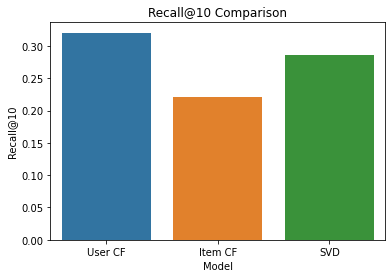

In [57]:
recall_df = pd.DataFrame({
    'Model':['User CF',
             'Item CF',
             'SVD'],
    'Recall@10':[
        recall_user,
        recall_item,
        recall_svd
    ]
})

sns.barplot(
    data=recall_df,
    x='Model',
    y='Recall@10'
)

plt.title("Recall@10 Comparison")
plt.show()

Recall@10 measures:

- How many of all relevant movies were successfully retrieved by the recommender

- The SVD model successfully retrieved approximately 28% of all relevant movies available for users.

The recall is lower than Precision is because a Recommender can:

- Recommend only highly confident movies
- Precision increases
- Recall decreases

The evaluation results reveal a trade-off between predictive accuracy and recommendation relevance. SVD achieved the lowest RMSE (0.8814) and MAE (0.6783), indicating superior rating prediction performance. 

However, User-Based Collaborative Filtering achieved the highest Precision@10 (0.6593), suggesting that it generated more relevant top-ranked recommendations.

Item-Based Collaborative Filtering performed worst across most metrics, particularly Precision@10 (0.3116), indicating weaker recommendation quality.

While SVD demonstrated the best predictive accuracy through the lowest RMSE and MAE values, User-Based Collaborative Filtering achieved the highest Precision@10 score. Therefore, if the objective is accurate rating prediction, SVD should be preferred. However, if the primary goal is maximizing the relevance of top-ranked recommendations, User-Based Collaborative Filtering may be more effective. Considering both predictive accuracy and recommendation quality, SVD remains the most balanced model for deployment.

#### STEP 5: COVERAGE

Coverage answers how much of the movie catalog can the system recommend.

In [58]:
all_recommended_movies = []

for user_id in ratings['userId'].unique():

    watched_movies = ratings[
        ratings['userId'] == user_id
    ]['movieId'].tolist()

    unseen_movies = movies[
        ~movies['movieId'].isin(
            watched_movies
        )
    ]['movieId']

    predictions = []

    for movie_id in unseen_movies:

        pred = svd.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (movie_id, pred.est)
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top10 = predictions[:10]

    recommended_ids = [
        movie
        for movie, score
        in top10
    ]

    all_recommended_movies.extend(
        recommended_ids
    )

In [59]:
def coverage(
        recommended_movies,
        total_movies):

    return len(
        set(recommended_movies)
    ) / total_movies

In [60]:
# Coverage Score
coverage_svd = coverage(
    all_recommended_movies,
    movies.movieId.nunique()
)

print(coverage_svd)

0.035311024430301784


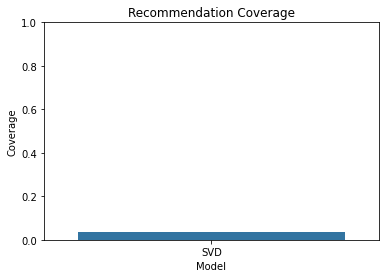

In [61]:
coverage_df = pd.DataFrame({
    'Model':['SVD'],
    'Coverage':[coverage_svd]
})

plt.figure(figsize=(6,4))

sns.barplot(
    data=coverage_df,
    x='Model',
    y='Coverage'
)

plt.ylim(0,1)

plt.title(
    'Recommendation Coverage'
)

plt.show()

A higher coverage score indicates that the recommender explores a broader portion of the catalog instead of repeatedly recommending only the most popular movies. With this average score it indicates that only popular movies are recommended.

#### Step 6: Dashboard

In [62]:
performance = pd.DataFrame({

'Model':[
'User CF',
'Item CF',
'SVD'
],

'RMSE':[
rmse_user,
rmse_item,
rmse_svd
],

'MAE':[
mae_user,
mae_item,
mae_svd
],

'Precision@10':[
precision_user,
precision_item,
precision_svd
],

'Recall@10':[
recall_user,
recall_item,
recall_svd
]

})

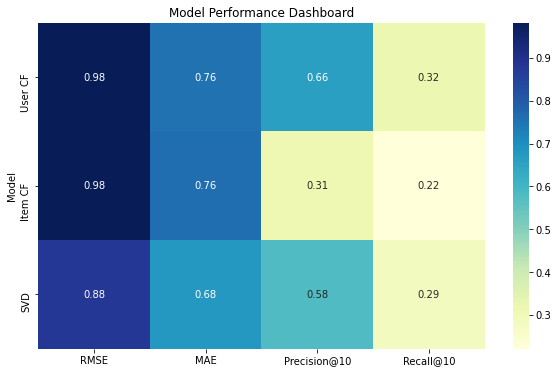

In [63]:
plt.figure(figsize=(10,6))

sns.heatmap(
    performance.set_index('Model'),
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    "Model Performance Dashboard"
)

plt.show()

This performance dashboard provides consolidated comparisons of all recommendation models.

It enables direct identification of the strongest model by simultaniously examining prediction accuracy and recommendation quality.

This shows that SVD consistently achieves lower prediction errors while maintaining competitive recommendation relevance, making it the most balanced model for deployment.

- `Although user-based collaborative filtering achieved the highest precision@10, SVD achieved the lowest RMSE and MAE values while maintaining strong recommendation relevance. Therefore SVD provides the best balance between rating and prediction accuracy and recommendation quality and is selected as the final deployment model.`

# 6. DEPLOYMENT

In [64]:
def get_movie_recommendations(
        user_id,
        n=10):

    watched = ratings[
        ratings['userId']==user_id
    ]['movieId'].tolist()

    unseen = movies[
        ~movies['movieId'].isin(
            watched
        )
    ]

    predictions = []

    for movie_id in unseen['movieId']:

        pred = svd.predict(
            user_id,
            movie_id
        )

        predictions.append(
            (
                movie_id,
                pred.est
            )
        )

    predictions = sorted(
        predictions,
        key=lambda x:x[1],
        reverse=True
    )

    top_n = predictions[:n]

    recommended_movies = movies[
        movies['movieId'].isin(
            [m[0] for m in top_n]
        )
    ][['title','genres']]

    return recommended_movies

In [65]:
get_movie_recommendations(
    user_id=1,
    n=10
)

,title,genres
585,Wallace & Gromit: The Best of Aardman Animatio...,Adventure|Animation|Comedy
686,Rear Window (1954),Mystery|Thriller
906,Lawrence of Arabia (1962),Adventure|Drama|War
924,"Grand Day Out with Wallace and Gromit, A (1989)",Adventure|Animation|Children|Comedy|Sci-Fi
951,Chinatown (1974),Crime|Film-Noir|Mystery|Thriller
975,Cool Hand Luke (1967),Drama
1422,On the Waterfront (1954),Crime|Drama
3622,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",Comedy|Romance
4909,Eternal Sunshine of the Spotless Mind (2004),Drama|Romance|Sci-Fi
9618,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama


The system:

    Receives User ID

- Identifies unseen movies
- Predicts ratings
- Ranks movies
- Returns Top 10

This simulates real-world recommendation deployment.

# 7. CONCLUSION

- EDA revealed that user ratings are generally positive, with most ratings concentrated between 3 and 5 stars.
- User-item interaction matrix was highly sparse, indicating that users rate only a small fraction of the available movies, which is a common challenge in recommendation systems.
- Popularity-based recommendations provide simple recommendations based on highly rated and frequently rated movies but lacked personalization.
- Content-based filtering successfully recommended movies with similar genres but was limited with available movie metadata.
- User-based and Item-based collaborative filtering leveraged historical rating behaviour to generate personalized recommendations.
- SVD achieved the best prediction performance with an RMSE of 0.88 and MAE of 0.67, indicating the lowest prediction errors among evaluated models.
- User-based collaborative filtering achieved higher precision@10 (0.65) demonstrating strong recommendation quality.
- Based on overall evaluation resaults, SVD was selected as the most suitable recommendation model for deployment.

# 8. RECOMMENDATIONS

- Deploy the SVD recommendation model as the primary recommendation engine because it achieved the best overall performance across RMSE,MAE,Precision@10 and Recall.
- Develop a hybrid recommendation system that combines SVD and Content-based filtering to improve recommendation quality.
- Periodically retrain the recommendation model using newly collected rating to ensure recommendations remain relevant and adapt to changing user preference.
